#### Import Libraries

In [40]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics import classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/jacquelinemcginley/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

#### Load Data

In [41]:
yelp = pd.read_csv("hotel_final.csv")

yelp.head()

,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,My husband took me to stay the night for a fun...,4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a...",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of th...",3,0,0,0
3,2985,ZLe,I'd like to make a confession. I don't really ...,3,21,11,16
4,2986,vURf9AGmThDrRC9TVcQrdw,The good: the view; location The bad: servic...,1,0,0,0


#### Inspect Data

In [42]:
print(yelp.shape)
print(yelp.columns)
yelp.info()
yelp.head()

(949, 7)
Index(['Unnamed: 0', 'reviewID', 'reviewContent', 'rating', 'usefulCount',
       'coolCount', 'funnyCount'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     949 non-null    int64 
 1   reviewID       949 non-null    object
 2   reviewContent  949 non-null    object
 3   rating         949 non-null    int64 
 4   usefulCount    949 non-null    int64 
 5   coolCount      949 non-null    int64 
 6   funnyCount     949 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 52.0+ KB


,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,My husband took me to stay the night for a fun...,4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a...",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of th...",3,0,0,0
3,2985,ZLe,I'd like to make a confession. I don't really ...,3,21,11,16
4,2986,vURf9AGmThDrRC9TVcQrdw,The good: the view; location The bad: servic...,1,0,0,0


#### Check for  Missing Values

In [43]:
yelp.isnull().sum()

Unnamed: 0       0
reviewID         0
reviewContent    0
rating           0
usefulCount      0
coolCount        0
funnyCount       0
dtype: int64

#### Create Sentiment Groups

In [44]:
def sentiment_group(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

yelp["sentiment_group"] = yelp["rating"].apply(sentiment_group)

yelp["sentiment_group"].value_counts()

sentiment_group
Positive    540
Neutral     207
Negative    202
Name: count, dtype: int64

#### Visualize Rating  Distribution

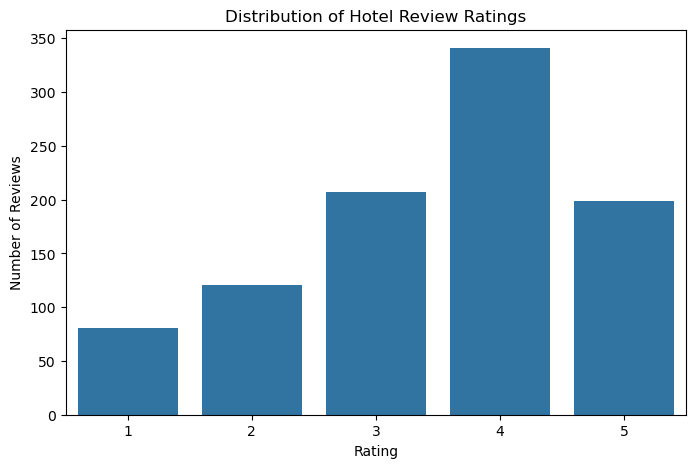

In [45]:
plt.figure(figsize = (8, 5))
sns.countplot(data = yelp, x = "rating")
plt.title("Distribution of Hotel Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

#### Visualize Sentiment Distribution

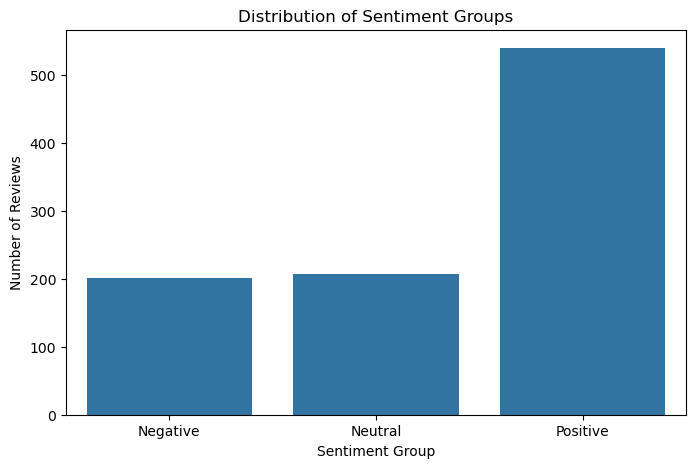

In [46]:
plt.figure(figsize = (8, 5))
sns.countplot(data = yelp, x = "sentiment_group", order=["Negative", "Neutral", "Positive"])
plt.title("Distribution of Sentiment Groups")
plt.xlabel("Sentiment Group")
plt.ylabel("Number of Reviews")
plt.show()

#### Clean Review Text

In [47]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

custom_stopwords = {
    "hotel", "room", "stay", "stayed", "night", "place", "would",
    "could", "also", "one", "get", "us", "like"
}

stop_words = stop_words.union(custom_stopwords)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(words)

yelp["cleanReview"] = yelp["reviewContent"].apply(clean_text)

yelp[["reviewContent", "cleanReview"]].head()

,reviewContent,cleanReview
0,My husband took me to stay the night for a fun...,husband took fun date year finally getting aro...
1,"stayed at the property over the weekend, got a...",property weekend got fantastic rate priceline ...
2,"Overall, I think I'm less and less a fan of th...",overall think less less fan concept good bad r...
3,I'd like to make a confession. I don't really ...,make confession really hotel much really whate...
4,The good: the view; location The bad: servic...,good view location bad service non existent ru...


#### Split Data Between Negative, Neutral, and  Positive

In [48]:
positive = yelp[yelp["sentiment_group"] == "Positive"].copy()
negative = yelp[yelp["sentiment_group"] == "Negative"].copy()
neutral = yelp[yelp["sentiment_group"] == "Neutral"].copy()

print("Positive:", positive.shape)
print("Negative:", negative.shape)
print("Neutral:", neutral.shape)

Positive: (540, 9)
Negative: (202, 9)
Neutral: (207, 9)


#### Create Function for Top Words

In [49]:
def get_top_words(text_series, n = 20):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(text_series)
    
    word_counts = X.sum(axis = 0).A1
    words = vectorizer.get_feature_names_out()
    
    word_freq = pd.DataFrame({
        "word": words,
        "count": word_counts
    }).sort_values(by = "count", ascending = False)
    
    return word_freq.head(n)

#### Identify Top Words in Total Dataset

In [50]:
topWords = get_top_words(yelp["cleanReview"], n = 20)
topWords

,word,count
2808,great,637
5368,room,549
4212,nice,500
1067,chicago,464
3697,lobby,460
5593,service,447
6486,time,438
567,bed,408
2761,good,393
3702,location,361


#### Visualize Top Words of Full Cleaned Dataset

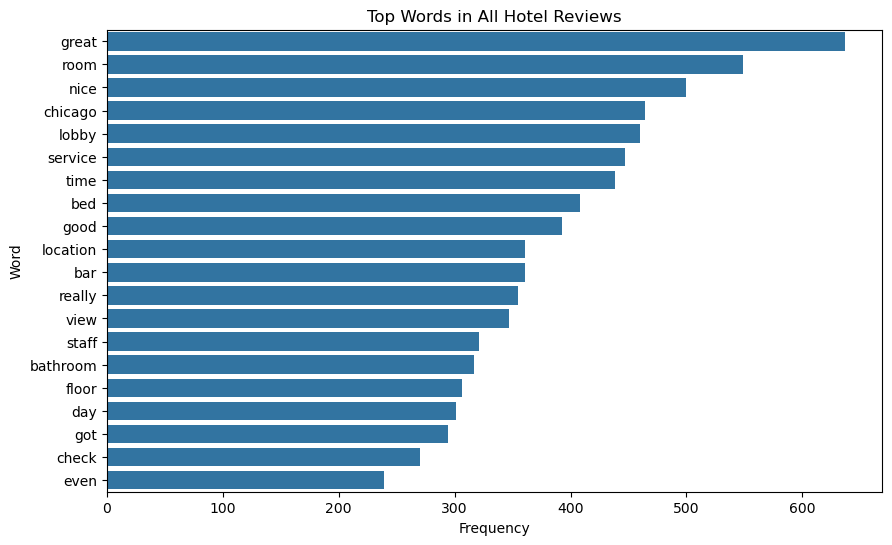

In [51]:
plt.figure(figsize = (10, 6))
sns.barplot(data = topWords, x = "count", y = "word")
plt.title("Top Words in All Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

#### Top Words in Positive Reviews

In [52]:
topWordsPos = get_top_words(positive["cleanReview"], n = 20)
topWordsPos

,word,count
1938,great,447
737,chicago,290
3715,room,285
2910,nice,280
2528,lobby,260
4494,time,235
1906,good,228
333,bar,221
4767,view,215
3870,service,215


#### Visualize Positive Words

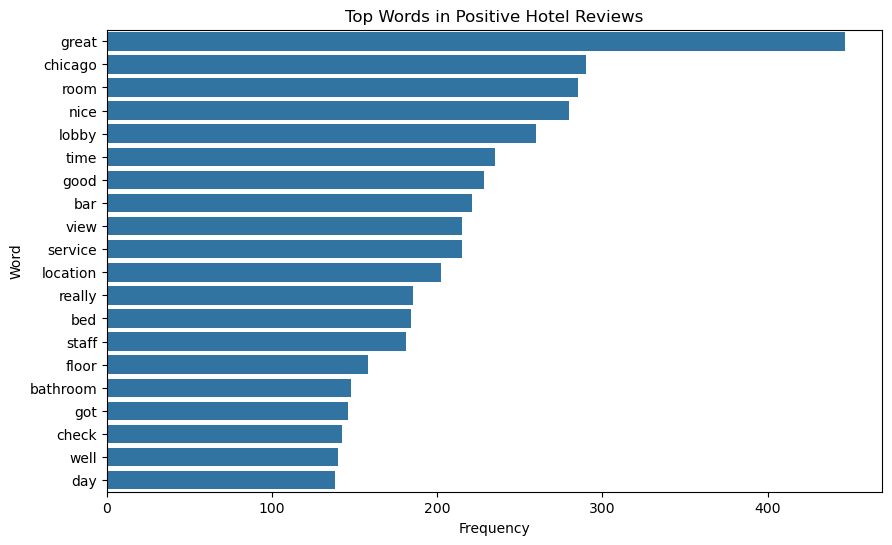

In [53]:
plt.figure(figsize = (10, 6))
sns.barplot(data = topWordsPos, x = "count", y = "word")
plt.title("Top Words in Positive Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

#### Top Words in Negative Reviews

In [54]:
topWordsNeg = get_top_words(negative["cleanReview"], n = 20)
topWordsNeg

,word,count
2841,service,152
2731,room,110
312,bed,108
885,desk,104
3284,time,98
819,day,97
1878,lobby,91
1346,front,90
1422,got,86
258,back,82


#### Visualize Negative Words

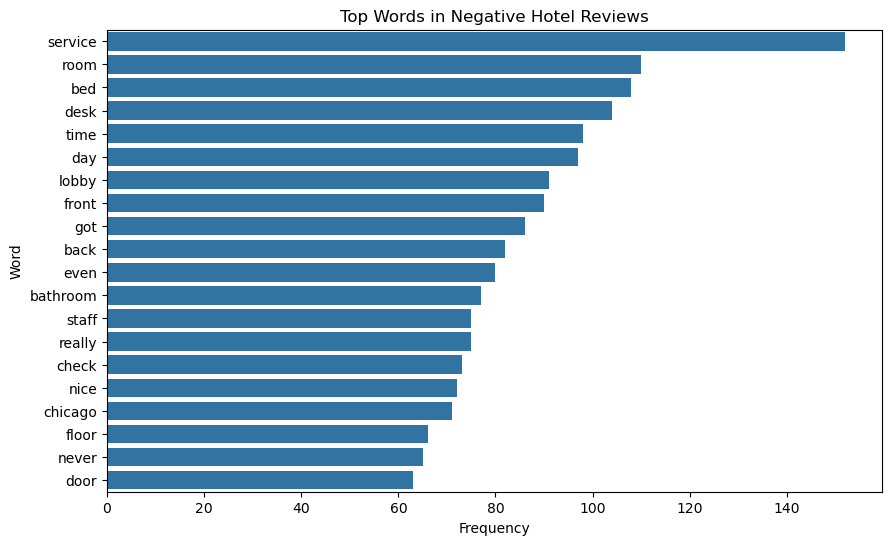

In [55]:
plt.figure(figsize = (10, 6))
sns.barplot(data = topWordsNeg, x = "count", y = "word")
plt.title("Top Words in Negative Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

#### Creat Function for Top N-Grams

In [56]:
def get_top_ngrams(text_series, ngram_range = (2, 2), n = 20):
    vectorizer = CountVectorizer(ngram_range = ngram_range)
    X = vectorizer.fit_transform(text_series)
    
    counts = X.sum(axis = 0).A1
    phrases = vectorizer.get_feature_names_out()
    
    phrase_freq = pd.DataFrame({
        "phrase": phrases,
        "count": counts
    }).sort_values(by="count", ascending=False)
    
    return phrase_freq.head(n)

#### Identify Top Bigrams in Positive Reviews

In [60]:
posBigrams = get_top_ngrams(
    positive["cleanReview"],
    ngram_range = (2, 2),
    n = 20
)

posBigrams

,phrase,count
17365,palmer house,113
16072,navy pier,55
9898,front desk,51
10877,great location,45
10955,great view,35
26121,walking distance,34
13922,lobby bar,31
19477,really nice,28
25841,view lake,28
15446,michigan ave,25


#### Visualize Positive Bigrams

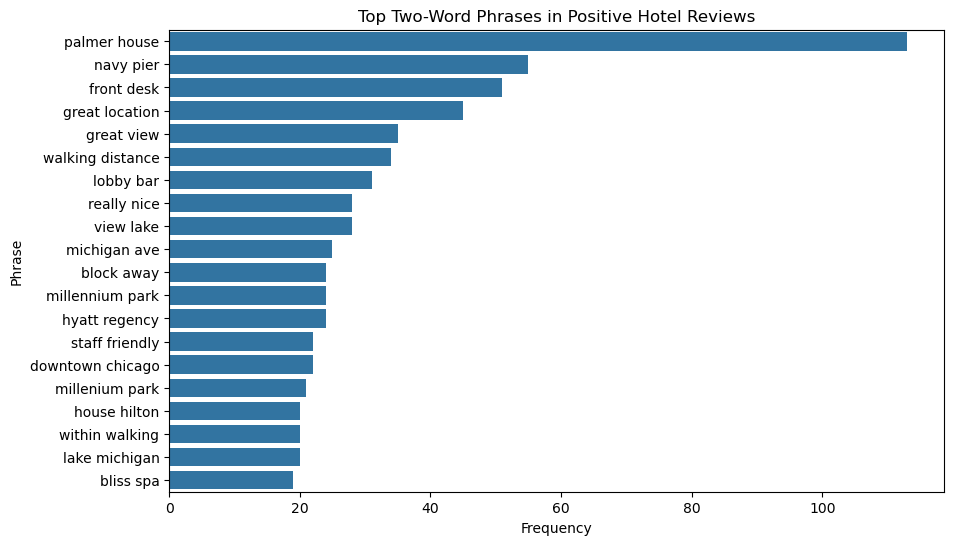

In [61]:
plt.figure(figsize = (10, 6))
sns.barplot(data = posBigrams, x = "count", y = "phrase")
plt.title("Top Two-Word Phrases in Positive Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Phrase")
plt.show()

#### Identify Top Bigrams in Negative Reviews

In [58]:
negBigrams = get_top_ngrams(
    negative["cleanReview"],
    ngram_range = (2, 2),
    n = 20
)

negBigrams

,phrase,count
5333,front desk,76
9361,palmer house,40
3179,customer service,21
1897,came back,12
8955,non smoking,12
4327,even though,12
3854,double bed,11
2649,come back,11
11016,room small,11
8826,next door,11


#### Visuzalize Negative Bigrams

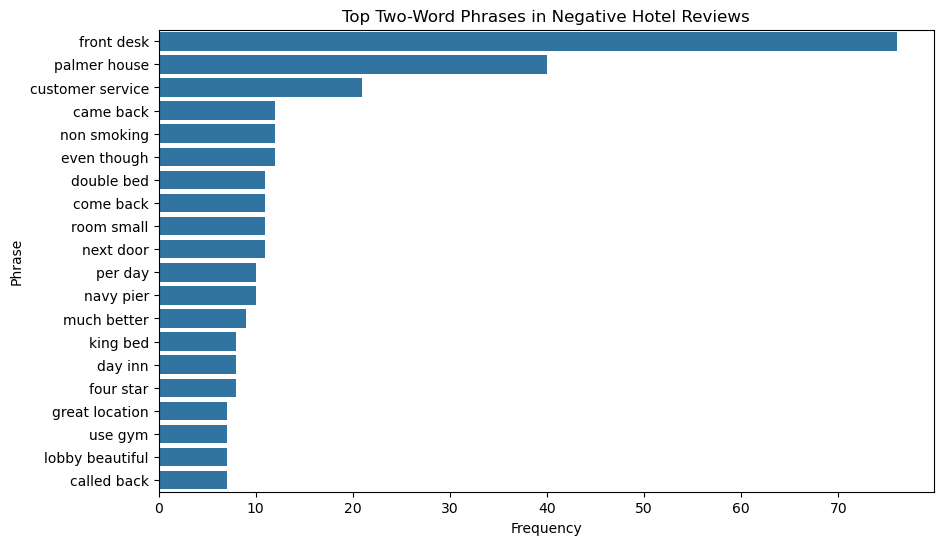

In [59]:
plt.figure(figsize = (10, 6))
sns.barplot(data = negBigrams, x = "count", y = "phrase")
plt.title("Top Two-Word Phrases in Negative Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Phrase")
plt.show()

#### Incorporate Review Length Feature

In [62]:
yelp["review_word_count"] = yelp["cleanReview"].apply(lambda x: len(x.split()))
yelp["review_char_count"] = yelp["reviewContent"].apply(lambda x: len(str(x)))

yelp[["rating", "sentiment_group", "review_word_count", "review_char_count"]].head()

,rating,sentiment_group,review_word_count,review_char_count
0,4,Positive,95,1203
1,3,Neutral,175,2056
2,3,Neutral,50,666
3,3,Neutral,216,2845
4,1,Negative,43,383


#### Compare Review Length By Sentiment

In [63]:
yelp.groupby("sentiment_group")[["review_word_count", "review_char_count"]].mean()

,review_word_count,review_char_count
sentiment_group,,
Negative,84.529703,1074.084158
Neutral,75.241546,940.772947
Positive,62.805556,769.522222
